In [16]:
# ─────────────────────────────────────────────────────────────
#  CELDA 1: Imports y Configuración Global
# ─────────────────────────────────────────────────────────────
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.signal import correlate
from dataclasses import dataclass, field
from typing import Literal
import os

# ── Constantes de modulación ──────────────────────────────────
ASK4_LEVELS   = np.array([0, 85, 170, 255], dtype=np.uint8)  # 4-ASK
BPSK_CHIPS    = {0: [0, 1], 1: [1, 0]}                       # Manchester
PILOT_VALUE   = 128                                           # gris medio conocido
MARKER_WHITE  = 255
MARKER_BLACK  = 0

# ── Configuración del módem ───────────────────────────────────
@dataclass
class ModemConfig:
    # Grilla de datos (sin contar celdas de marcadores/pilotos)
    M: int = 36          # filas de macropíxeles
    N: int = 64          # columnas de macropíxeles
    cell_size: int = 20  # píxeles por lado de cada celda
    
    # Resultado: 36*20 = 720 px (alto), 64*20 = 1280 px (ancho) ✓

    # Modulación
    scheme: Literal["BPSK_Manchester", "4ASK"] = "BPSK_Manchester"

    # Estructura de trama
    marker_cells: int = 3    # tamaño del finder pattern en celdas (3×3)
    pilot_period: int = 4    # insertar piloto cada N celdas de datos

    # Temporización
    symbol_duration_ms: int = 100
    screen_fps: int = 60
    camera_fps: int = 30

    # ── Propiedades derivadas ──────────────────────────────────
    @property
    def frame_width(self) -> int:
        return self.N * self.cell_size

    @property
    def frame_height(self) -> int:
        return self.M * self.cell_size

    @property
    def bits_per_symbol(self) -> int:
        return 1 if self.scheme == "BPSK_Manchester" else 2

    @property
    def chips_per_symbol(self) -> int:
        """Chips que ocupa un símbolo en la grilla (Manchester duplica)."""
        return 2 if self.scheme == "BPSK_Manchester" else 1

    @property
    def total_cells(self) -> int:
        return self.M * self.N

    @property
    def reserved_cells(self) -> int:
        """Celdas ocupadas por los 3 marcadores finder."""
        return 3 * (self.marker_cells ** 2)

    @property
    def available_data_cells(self) -> int:
        return self.total_cells - self.reserved_cells

    @property
    def max_payload_bits(self) -> int:
        """Bits de usuario máximos por trama (descontando pilotos)."""
        pilot_count  = self.available_data_cells // self.pilot_period
        payload_cells = self.available_data_cells - pilot_count
        # En Manchester, cada celda transporta 1 chip = 0.5 bits efectivos
        if self.scheme == "BPSK_Manchester":
            return (payload_cells // 2) * 1   # 2 chips → 1 bit
        return payload_cells * self.bits_per_symbol

    def summary(self):
        print(f"{'─'*46}")
        print(f"  Esquema        : {self.scheme}")
        print(f"  Grilla         : {self.M}×{self.N}  ({self.total_cells} celdas)")
        print(f"  Tamaño celda   : {self.cell_size}×{self.cell_size} px")
        print(f"  Imagen         : {self.frame_width}×{self.frame_height} px")
        print(f"  Celdas libres  : {self.available_data_cells}")
        print(f"  Payload máx.   : {self.max_payload_bits} bits  "
            f"({self.max_payload_bits // 8} bytes)")
        print(f"  Duración símbolo: {self.symbol_duration_ms} ms")
        print(f"{'─'*46}")


# ── Instancia por defecto ─────────────────────────────────────
cfg = ModemConfig(scheme="BPSK_Manchester")
#cfg = ModemConfig(scheme="4ASK")
cfg.summary()

──────────────────────────────────────────────
  Esquema        : BPSK_Manchester
  Grilla         : 36×64  (2304 celdas)
  Tamaño celda   : 20×20 px
  Imagen         : 1280×720 px
  Celdas libres  : 2277
  Payload máx.   : 854 bits  (106 bytes)
  Duración símbolo: 100 ms
──────────────────────────────────────────────


── Loopback capa-2 ───────────────────────────────────
  ✓ [BPSK_Manchester     ]  'Hola mundo!'  │   176 símbolos  │  gris medio = 127.5 / 255
  ✓ [4ASK                ]  'Hola mundo!'  │    44 símbolos  │  gris medio = 123.6 / 255


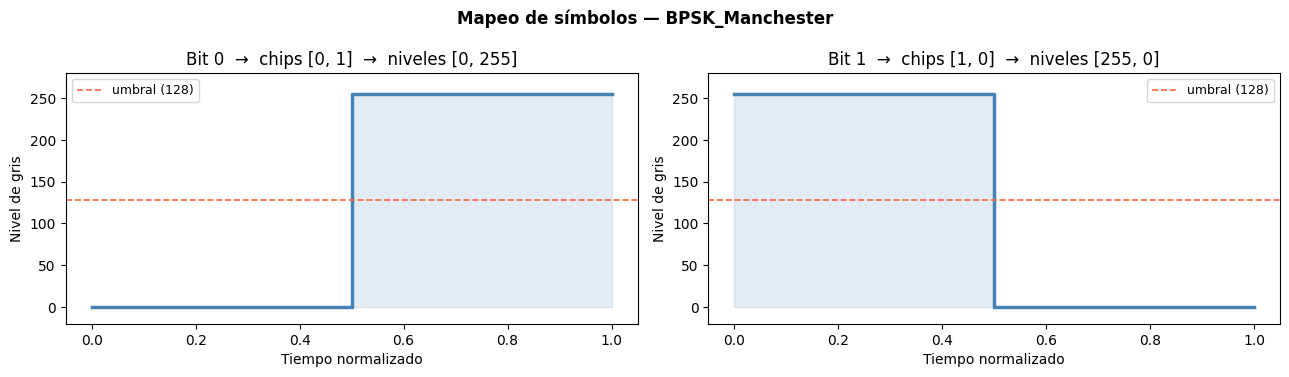

In [17]:
# ─────────────────────────────────────────────────────────────
#  CELDA 2: Codificación de fuente y Mapeo bits → símbolos
# ─────────────────────────────────────────────────────────────

# ── 2.1 Texto ↔ Bits ─────────────────────────────────────────

def text_to_bits(text: str) -> np.ndarray:
    """UTF-8 → array plano de bits (MSB primero por byte)."""
    raw = np.frombuffer(text.encode("utf-8"), dtype=np.uint8)
    return np.unpackbits(raw)

def bits_to_text(bits: np.ndarray) -> str:
    """Inversa de text_to_bits. Trunca al byte completo más cercano."""
    n = (len(bits) // 8) * 8
    return np.packbits(bits[:n]).tobytes().decode("utf-8", errors="replace")


# ── 2.2 BPSK + Codificación Manchester ───────────────────────
#
#   Bit 0 → chips [0, 1]  (transición ↑, low→high)
#   Bit 1 → chips [1, 0]  (transición ↓, high→low)
#
#   Beneficios:
#     • gris medio = 128 siempre → balance DC garantizado
#     • transición en cada periodo → facilita recovery de reloj
#     • 2× chips por bit → la tasa de celda dobla a la de bit

def bpsk_manchester_modulate(bits: np.ndarray) -> np.ndarray:
    """bits → niveles de gris {0, 255} con codificación Manchester."""
    chips = np.empty(len(bits) * 2, dtype=np.uint8)
    chips[0::2] = bits          # chip par   = bit
    chips[1::2] = 1 - bits      # chip impar = complemento
    return (chips * 255).astype(np.uint8)

def bpsk_manchester_demodulate(symbols: np.ndarray,
                                threshold: int = 128) -> np.ndarray:
    """Símbolos grises → bits vía umbral + extracción del chip par."""
    chips = (symbols >= threshold).astype(np.uint8)
    return chips[0::2]           # chip par codifica el bit directamente


# ── 2.3 4-ASK con código Gray ────────────────────────────────
#
#   Código Gray garantiza que simbolos adyacentes difieran en 1 solo bit,
#   minimizando BER cuando el ruido desplaza un nivel.
#
#   Dibit  Nivel  Brillo
#   ─────  ─────  ──────
#    00      0     0 %
#    01     85    33 %
#    11    170    67 %
#    10    255   100 %

_4ASK_MAP = {
    (0, 0): ASK4_LEVELS[0],   # 00 →   0
    (0, 1): ASK4_LEVELS[1],   # 01 →  85
    (1, 1): ASK4_LEVELS[2],   # 11 → 170
    (1, 0): ASK4_LEVELS[3],   # 10 → 255
}
_4ASK_INV = {int(v): k for k, v in _4ASK_MAP.items()}

def ask4_modulate(bits: np.ndarray) -> np.ndarray:
    """
    Agrupa en dibits y mapea a niveles 4-ASK.
    Añade bit de relleno (0) si len(bits) es impar.
    """
    if len(bits) % 2:
        bits = np.append(bits, 0)
    return np.array(
        [_4ASK_MAP[tuple(b)] for b in bits.reshape(-1, 2)],
        dtype=np.uint8
    )

def ask4_demodulate(symbols: np.ndarray) -> np.ndarray:
    """Cuantiza al nivel más cercano y recupera dibits."""
    nearest_idx = np.argmin(
        np.abs(symbols.astype(int)[:, None] - ASK4_LEVELS.astype(int)),
        axis=1
    )
    nearest = ASK4_LEVELS[nearest_idx]
    return np.concatenate([_4ASK_INV[int(s)] for s in nearest]).astype(np.uint8)


# ── 2.4 Interfaz unificada ────────────────────────────────────

def bits_to_symbols(bits: np.ndarray, config: ModemConfig) -> np.ndarray:
    if config.scheme == "BPSK_Manchester":
        return bpsk_manchester_modulate(bits)
    if config.scheme == "4ASK":
        return ask4_modulate(bits)
    raise ValueError(f"Esquema desconocido: {config.scheme}")

def symbols_to_bits(symbols: np.ndarray, config: ModemConfig) -> np.ndarray:
    if config.scheme == "BPSK_Manchester":
        return bpsk_manchester_demodulate(symbols)
    if config.scheme == "4ASK":
        return ask4_demodulate(symbols)
    raise ValueError(f"Esquema desconocido: {config.scheme}")


# ── 2.5 Auto-verificación loopback capa-2 ────────────────────

def _loopback_test(text: str, config: ModemConfig) -> bool:
    bits      = text_to_bits(text)
    symbols   = bits_to_symbols(bits, config)
    rec_bits  = symbols_to_bits(symbols, config)
    rec_text  = bits_to_text(rec_bits[:len(bits)])
    ok        = (rec_text == text)
    print(
        f"  {'✓' if ok else '✗ ERROR'} "
        f"[{config.scheme:<20s}]  "
        f"'{text}'  │  {len(symbols):>4d} símbolos  │  "
        f"gris medio = {symbols.mean():.1f} / 255"
    )
    return ok

print("── Loopback capa-2 ───────────────────────────────────")
for scheme in ("BPSK_Manchester", "4ASK"):
    _loopback_test("Hola mundo!", ModemConfig(scheme=scheme))


# ── 2.6 Visualización del mapeo ───────────────────────────────

def plot_symbol_mapping(config: ModemConfig):
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

    if config.scheme == "BPSK_Manchester":
        for ax, (bit, chips) in zip(axes, [(0, [0,1]), (1, [1,0])]):
            t = [0, 0.5, 0.5, 1.0]
            v = [chips[0]*255, chips[0]*255, chips[1]*255, chips[1]*255]
            ax.plot(t, v, color='steelblue', linewidth=2.5, drawstyle='steps-post')
            ax.fill_between(t, v, alpha=0.15, color='steelblue', step='post')
            ax.axhline(128, color='tomato', linestyle='--', linewidth=1.2,
                        label='umbral (128)')
            ax.set_title(f"Bit {bit}  →  chips {chips}  →  "
                        f"niveles {[c*255 for c in chips]}")
            ax.set_ylim(-20, 280); ax.set_ylabel("Nivel de gris")
            ax.set_xlabel("Tiempo normalizado"); ax.legend(fontsize=9)

    else:
        ax1, ax2 = axes
        for (d0, d1), level in _4ASK_MAP.items():
            color = plt.cm.plasma(level / 255)
            ax1.scatter(level, 0, s=350, color=color, zorder=5, edgecolors='k')
            ax1.annotate(f"{d0}{d1}", (level, 0.012),
                        ha='center', fontsize=12, fontweight='bold')
        ax1.set_xlim(-20, 275); ax1.set_yticks([])
        ax1.set_xlabel("Nivel de gris"); ax1.set_title("Constelación 4-ASK (Gray code)")

        ax2.axis('off')
        tbl = ax2.table(
            cellText=[[f"{d0}{d1}", str(lv), f"{round(lv/255*100)}%"]
                    for (d0,d1), lv in _4ASK_MAP.items()],
            colLabels=["Dibit (Gray)", "Nivel", "Brillo"],
            loc='center', cellLoc='center'
        )
        tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.2, 1.8)
        ax2.set_title("Tabla de mapeo")

    plt.suptitle(f"Mapeo de símbolos — {config.scheme}", fontweight='bold')
    plt.tight_layout(); plt.show()

plot_symbol_mapping(cfg)

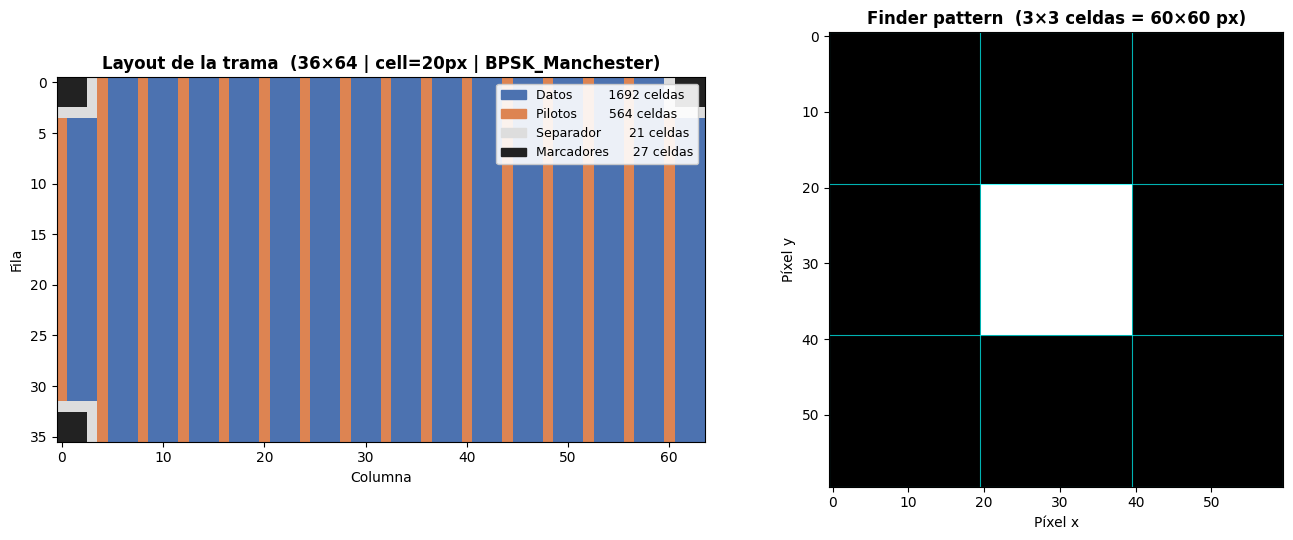

  Total celdas   : 2304
  Marcadores     : 27  (3 finders × 3² = 27)
  Separadores    : 21
  Pilotos        : 564  (1 cada 4 celdas libres)
  Datos          : 1692
  Payload máximo : 846 bits  (105 bytes)  [BPSK_Manchester]
  Reproducibilidad del layout: ✓ determinista


In [18]:
# ─────────────────────────────────────────────────────────────
#  CELDA 3: Marcadores fiduciales y distribución de celdas piloto
# ─────────────────────────────────────────────────────────────
#
#  NOTA: Para robustez en la detección de esquinas con OpenCV se
#  recomienda actualizar la Celda 1 con marker_cells=7, M=20, N=20.
#  Todo el código funciona con cualquier valor de marker_cells >= 3.
# ─────────────────────────────────────────────────────────────

# ── 3.1 Patrón finder concéntrico (estilo QR) ────────────────
#
#   La estructura de anillos garantiza que el patrón sea fácilmente
#   distinguible del payload, independientemente del nivel de gris
#   de los datos circundantes.
#
#    size=3    size=5       size=7
#    ■ ■ ■    ■ ■ ■ ■ ■   ■ ■ ■ ■ ■ ■ ■
#    ■ · ■    ■ · · · ■   ■ · · · · · ■
#    ■ ■ ■    ■ · ■ · ■   ■ · ■ ■ ■ · ■
#             ■ · · · ■   ■ · ■ ■ ■ · ■
#             ■ ■ ■ ■ ■   ■ · ■ ■ ■ · ■
#                         ■ · · · · · ■
#                         ■ ■ ■ ■ ■ ■ ■

def generate_finder_pattern(size: int) -> np.ndarray:
    """
    Patrón binario size×size: 1=módulo oscuro, 0=módulo claro.
    Anillo exterior (1 módulo) oscuro → separador claro → bloque central oscuro.
    """
    if size < 3:
        raise ValueError("marker_cells debe ser >= 3")

    pat = np.zeros((size, size), dtype=np.uint8)

    # Anillo exterior oscuro
    pat[0, :] = pat[-1, :] = 1
    pat[:, 0] = pat[:, -1] = 1

    # Bloque central oscuro (si hay espacio para el separador interior)
    if size >= 5:
        cs = size - 4          # lado del bloque: siempre ≥1
        pat[2:2+cs, 2:2+cs] = 1

    return pat


def render_finder_to_pixels(pattern: np.ndarray,
                            cell_size: int) -> np.ndarray:
    """
    Upscaling por kron: cada módulo → cell_size × cell_size px.
    Convención de imagen: módulo oscuro (1) → 0, claro (0) → 255.
    """
    px = np.kron(pattern, np.ones((cell_size, cell_size), dtype=np.uint8))
    return ((1 - px) * 255).astype(np.uint8)


# ── 3.2 Layout completo de la trama ──────────────────────────

def compute_frame_layout(config: ModemConfig) -> dict:
    """
    Asigna cada celda (r, c) de la grilla M×N a una de cuatro categorías:
    'marker'    → ocupada por un finder (3 esquinas, estilo QR)
    'separator' → borde blanco de 1 celda alrededor de cada finder
    'pilot'     → cada pilot_period celdas libres, para calibración
    'data'      → celdas disponibles para payload
    'corners'   → lista de esquinas (r0, c0) de los 3 finders

    La asignación es determinista y pública: el receptor puede reproducirla
    sin canalizarla como overhead, con solo conocer M, N y marker_cells.
    """
    M, N, ms = config.M, config.N, config.marker_cells

    if N < 2 * ms + 1 or M < 2 * ms + 1:
        raise ValueError(
            f"Grilla {M}×{N} demasiado pequeña para marker_cells={ms}. "
            f"Mínimo M=N={2*ms+1}."
        )

    # Esquinas superiores-izquierdas de los 3 finders (como en QR codes)
    corners = [
        (0,       0      ),   # ← top-left
        (0,       N - ms ),   # ← top-right
        (M - ms,  0      ),   # ← bottom-left
        # bottom-right queda libre (puede usarse para metadatos en fases futuras)
    ]

    # ── Celdas de marcadores ──────────────────────────────────
    marker_set = set()
    for r0, c0 in corners:
        for dr in range(ms):
            for dc in range(ms):
                marker_set.add((r0 + dr, c0 + dc))

    # ── Separador: 1 celda de borde blanco alrededor de cada finder ──
    sep_set = set()
    for r0, c0 in corners:
        for dr in range(-1, ms + 1):
            for dc in range(-1, ms + 1):
                r, c = r0 + dr, c0 + dc
                if 0 <= r < M and 0 <= c < N and (r, c) not in marker_set:
                    sep_set.add((r, c))

    # ── Celdas libres en orden raster ────────────────────────
    reserved = marker_set | sep_set
    free = [
        (r, c)
        for r in range(M)
        for c in range(N)
        if (r, c) not in reserved
    ]

    # ── Distribuir pilotos y datos ────────────────────────────
    pilot_positions = []
    data_positions  = []
    for idx, pos in enumerate(free):
        if idx % config.pilot_period == 0:
            pilot_positions.append(pos)
        else:
            data_positions.append(pos)

    return {
        "marker"   : marker_set,
        "separator": sep_set,
        "pilot"    : pilot_positions,
        "data"     : data_positions,
        "corners"  : corners,
    }


# ── 3.3 Valores de pilotos ────────────────────────────────────
#
#  Alternamos negro (0) y blanco (255). Esto permite al receptor
#  estimar dos incógnitas de calibración lineal:
#
#    y_recv = a · x_tx + b
#
#  Con un par (0→b,  255→255a+b) se resuelve:  a = (y₂-y₁)/255,  b = y₁
#  Para calibración por región, se usan pares de pilotos cercanos.

_PILOT_SEQ = np.array([0, 255, 0, 255], dtype=np.uint8)

def generate_pilot_values(n: int) -> np.ndarray:
    """n valores piloto alternando 0↔255 de forma determinista."""
    return _PILOT_SEQ[np.arange(n) % len(_PILOT_SEQ)]


# ── 3.4 Dibujar marcadores sobre imagen ──────────────────────

def draw_markers_on_frame(frame: np.ndarray,
                        layout: dict,
                        config: ModemConfig) -> np.ndarray:
    """
    Escribe los 3 patrones finder y el separador blanco sobre la
    imagen grayscale `frame` (uint8). Modifica in-place y retorna.
    """
    pattern_px = render_finder_to_pixels(
        generate_finder_pattern(config.marker_cells), config.cell_size
    )
    cs  = config.cell_size
    sz  = config.marker_cells * cs

    for (r0, c0) in layout["corners"]:
        y0, x0 = r0 * cs, c0 * cs
        frame[y0:y0+sz, x0:x0+sz] = pattern_px

    for (r, c) in layout["separator"]:
        y0, x0 = r * cs, c * cs
        frame[y0:y0+cs, x0:x0+cs] = 255       # separador blanco

    return frame


# ── 3.5 Visualización del layout ─────────────────────────────

def plot_frame_layout(layout: dict, config: ModemConfig):
    """Mapa de colores 2-D + zoom del finder pattern con grid de celdas."""
    from matplotlib.colors import ListedColormap

    COLORS = ['#4C72B0', '#DD8452', '#DDDDDD', '#222222']  # datos, pilotos, sep, marker
    cmap = ListedColormap(COLORS)

    grid = np.zeros((config.M, config.N), dtype=np.uint8)
    for pos in layout["data"]     : grid[pos] = 0
    for pos in layout["pilot"]    : grid[pos] = 1
    for pos in layout["separator"]: grid[pos] = 2
    for pos in layout["marker"]   : grid[pos] = 3

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # — Mapa de celdas —
    axes[0].imshow(grid, cmap=cmap, vmin=0, vmax=3, interpolation='nearest')
    axes[0].set_title(
        f"Layout de la trama  "
        f"({config.M}×{config.N} | cell={config.cell_size}px | {config.scheme})",
        fontweight='bold'
    )
    axes[0].set_xlabel("Columna"); axes[0].set_ylabel("Fila")
    patches = [
        mpatches.Patch(color=COLORS[0], label=f"Datos        {len(layout['data']):>5d} celdas"),
        mpatches.Patch(color=COLORS[1], label=f"Pilotos      {len(layout['pilot']):>5d} celdas"),
        mpatches.Patch(color=COLORS[2], label=f"Separador    {len(layout['separator']):>5d} celdas"),
        mpatches.Patch(color=COLORS[3], label=f"Marcadores   {len(layout['marker']):>5d} celdas"),
    ]
    axes[0].legend(handles=patches, fontsize=9, loc='upper right',
                    framealpha=0.9)

    # — Finder pattern ampliado —
    fp_px = render_finder_to_pixels(
        generate_finder_pattern(config.marker_cells), config.cell_size
    )
    axes[1].imshow(fp_px, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
    axes[1].set_title(
        f"Finder pattern  "
        f"({config.marker_cells}×{config.marker_cells} celdas = "
        f"{fp_px.shape[1]}×{fp_px.shape[0]} px)",
        fontweight='bold'
    )
    # Grid de celdas sobre el finder
    for k in range(0, fp_px.shape[1] + 1, config.cell_size):
        axes[1].axvline(k - 0.5, color='cyan', lw=0.8, alpha=0.7)
    for k in range(0, fp_px.shape[0] + 1, config.cell_size):
        axes[1].axhline(k - 0.5, color='cyan', lw=0.8, alpha=0.7)
    axes[1].set_xlabel("Píxel x"); axes[1].set_ylabel("Píxel y")

    plt.tight_layout()
    plt.show()

    # — Resumen numérico —
    n_data   = len(layout['data'])
    n_pilots = len(layout['pilot'])
    max_bits = (n_data // 2) if config.scheme == "BPSK_Manchester" else n_data * 2

    print(f"  Total celdas   : {config.M * config.N}")
    print(f"  Marcadores     : {len(layout['marker'])}  "
        f"(3 finders × {config.marker_cells}² = {3*config.marker_cells**2})")
    print(f"  Separadores    : {len(layout['separator'])}")
    print(f"  Pilotos        : {n_pilots}  (1 cada {config.pilot_period} celdas libres)")
    print(f"  Datos          : {n_data}")
    print(f"  Payload máximo : {max_bits} bits  ({max_bits // 8} bytes)  [{config.scheme}]")

    # Verificar que layout es reproducible (receptor puede recalcular)
    layout2 = compute_frame_layout(config)
    ok = (layout2["data"] == layout["data"] and
        layout2["pilot"] == layout["pilot"])
    print(f"  Reproducibilidad del layout: {'✓ determinista' if ok else '✗ ERROR'}")


# ── Ejecutar ──────────────────────────────────────────────────
layout = compute_frame_layout(cfg)
plot_frame_layout(layout, cfg)

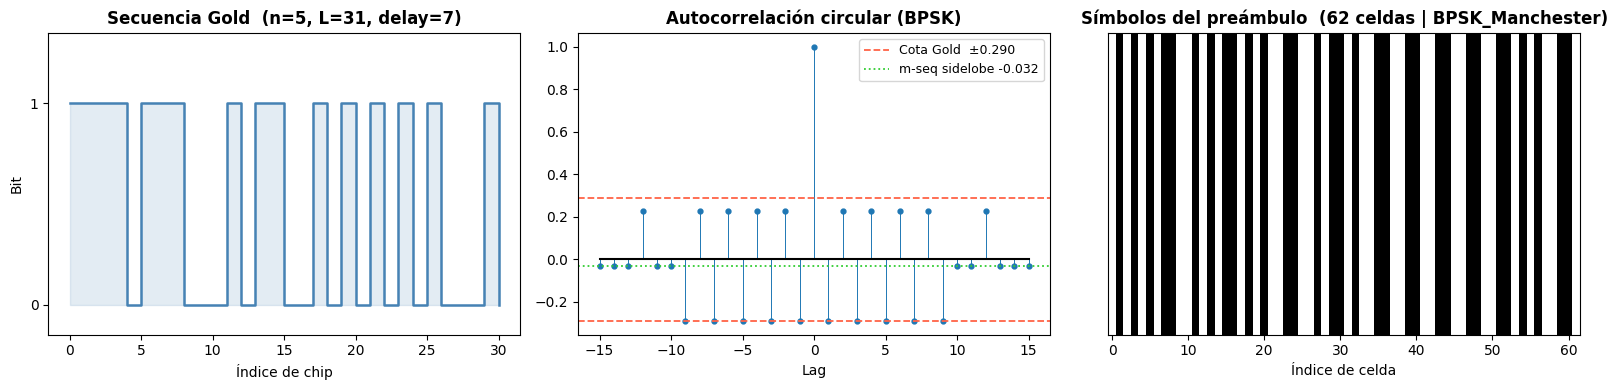

  Longitud secuencia Gold   : 31 chips  (n=5)
  Período verificado        : ✓
  Celdas del preámbulo      : 62
  Celdas payload restantes  : 1630
  Payload efectivo          : 815 bits  (101 bytes)
  Sidelobe AC m-secuencia   : -0.0323  (ideal)
  Cota correlación cruzada  : ±0.2903


In [19]:
# ─────────────────────────────────────────────────────────────
#  CELDA 4: Preámbulo — Secuencias Gold y sincronización de trama
# ─────────────────────────────────────────────────────────────
#
#  Rol del preámbulo en la trama espacial:
#    • Los finders (celda 3) resuelven DÓNDE está la grilla.
#    • El preámbulo resuelve QUÉ celda es cuál dentro del área de datos
#      (resuelve permutaciones espaciales residuales post-homografía).
#    • Autocorrelación con pico agudo → confirma identidad de trama.
# ─────────────────────────────────────────────────────────────

# ── 4.1 LFSR de Fibonacci → m-secuencia ──────────────────────
#
#  Derivación de rec_taps desde p(x):
#    La recurrencia lineal de p(x)=x^n+...+1 es:
#      a_{t+n} = Σ_{coeficientes c_k≠0, k<n} a_{t+k}
#    Reescrita para el "siguiente bit dado el estado actual":
#      a_{t+1} = Σ state[n-1-k]   donde k recorre los exponentes no nulos
#
#  Pares verificados (polinomios primitivos GF(2), grado 5):
#    p1 = x^5+x^2+1         →  rec_taps1 = (2, 4)
#         recurrencia: a_t = a_{t-3} ⊕ a_{t-5}
#    p2 = x^5+x^3+x^2+x+1  →  rec_taps2 = (1, 2, 3, 4)
#         recurrencia: a_t = a_{t-2} ⊕ a_{t-3} ⊕ a_{t-4} ⊕ a_{t-5}

def m_sequence(n: int,
                rec_taps: tuple,
                seed: list | None = None) -> np.ndarray:
    """
    Genera m-secuencia binaria de longitud 2^n − 1.

    Estado: [a_t, a_{t-1}, …, a_{t-n+1}]  (reciente primero).
    state[0] es la salida; rec_taps indexa el estado (0-based) para el XOR
    que produce el siguiente bit.
    """
    if seed is None:
        seed = [1] + [0] * (n - 1)   # seed ≠ 0 garantiza período máximo

    state  = list(seed[:n])
    length = (1 << n) - 1
    out    = np.empty(length, dtype=np.uint8)

    for i in range(length):
        out[i] = state[0]                      # salida = bit más reciente
        fb = 0
        for t in rec_taps:
            fb ^= state[t]
        state = [fb] + state[:-1]              # desplazamiento derecho

    return out


def _verify_mseq_period(seq: np.ndarray) -> bool:
    """Comprueba que la secuencia tiene período exactamente len(seq)."""
    n = len(seq)
    for k in range(1, n):
        if np.all(seq == np.roll(seq, k)):
            return False
    return True


# ── 4.2 Secuencia Gold ────────────────────────────────────────
#
#  Gold(n=5): familia de 2^5+1 = 33 secuencias, todas de longitud 31.
#  Correlación cruzada acotada ∈ {−1, −(t−2), +(t−2)} / L
#  donde  t(n) = 1 + 2^((n+1)/2)  para n impar.
#  Para n=5: t=9, L=31  →  |CC| ≤ 8/31 ≈ 0.26  <<  pico AC = 1.0.
#
#  La familia se genera como  g_k = m1 ⊕ T^k(m2)  para k = 0,1,…,L-1
#  más las dos m-secuencias solas: total 2^n+1 = 33 secuencias.

_TAPS_P1 = (2, 4)          # x^5+x^2+1
_TAPS_P2 = (1, 2, 3, 4)   # x^5+x^3+x^2+x+1

def gold_sequence(n: int   = 5,
                taps1    = _TAPS_P1,
                taps2    = _TAPS_P2,
                delay    : int = 7) -> np.ndarray:
    """
    Secuencia Gold = m1 ⊕ T^delay(m2).
    delay ∈ [1, 2^n−2] permite seleccionar un miembro distinto de la familia.
    """
    m1 = m_sequence(n, taps1)
    m2 = m_sequence(n, taps2)
    return (m1 ^ np.roll(m2, delay)).astype(np.uint8)


# ── 4.3 Autocorrelación circular (BPSK) ──────────────────────

def circular_autocorr(seq: np.ndarray) -> np.ndarray:
    """
    Autocorrelación circular con mapeo 0→−1, 1→+1.
    Normalizada: pico en lag=0 = 1.0.
    Para m-secuencia pura: sidelobe = −1/L  (plano e ideal).
    Para Gold: sidelobes ≤ t(n)/L.
    """
    bpsk = 2.0 * seq.astype(float) - 1.0
    S    = np.fft.fft(bpsk)
    corr = np.real(np.fft.ifft(S * np.conj(S)))
    return corr / corr[0]


# ── 4.4 Construcción del preámbulo en la trama ───────────────

def build_preamble(config: ModemConfig,
                    layout: dict,
                    n_lfsr: int = 5,
                    delay:  int = 7) -> dict:
    """
    Reserva las primeras celdas de layout['data'] para el preámbulo.
    Los símbolos se generan con el mismo esquema de modulación que el payload
    → el receptor puede usar el mismo demodulador para ambos.

    Returns
    -------
    'sequence'       : bits Gold (uint8)
    'symbols'        : niveles de gris por celda de preámbulo
    'n_cells'        : número de celdas consumidas
    'preamble_cells' : lista de (r, c) del preámbulo
    'data_positions' : celdas restantes para el payload real
    """
    seq = gold_sequence(n_lfsr, delay=delay)

    # 4-ASK requiere número par de bits (2 bits/símbolo)
    if config.scheme == "4ASK" and len(seq) % 2 != 0:
        seq = seq[:-1]

    syms    = bits_to_symbols(seq, config)
    n_cells = len(syms)
    free    = layout["data"]

    if n_cells > len(free):
        raise ValueError(
            f"Preámbulo necesita {n_cells} celdas pero solo hay "
            f"{len(free)} disponibles. "
            f"Aumenta M/N o reduce n_lfsr."
        )

    return {
        "sequence"       : seq,
        "symbols"        : syms,
        "n_cells"        : n_cells,
        "preamble_cells" : free[:n_cells],
        "data_positions" : free[n_cells:],    # ← aquí va el payload real
    }


# ── 4.5 Visualización ─────────────────────────────────────────

def plot_preamble(preamble: dict, config: ModemConfig):
    seq   = preamble["sequence"]
    syms  = preamble["symbols"]
    acorr = circular_autocorr(seq)

    L    = len(seq)
    n    = int(np.round(np.log2(L + 1)))
    lags = np.arange(L) - L // 2

    # Autocorrelación centrada en lag=0
    acorr_c = np.roll(acorr, L // 2)

    # Cota teórica de correlación para Gold (n impar)
    t_n    = 1 + 2 ** ((n + 1) // 2)
    bound  = t_n / L
    sl_ref = -1.0 / L          # sidelobe ideal m-secuencia

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # — Secuencia Gold —
    axes[0].step(np.arange(L), seq, where='post',
                color='steelblue', linewidth=1.8)
    axes[0].fill_between(np.arange(L), seq, step='post',
                        alpha=0.15, color='steelblue')
    axes[0].set_title(f"Secuencia Gold  (n={n}, L={L}, delay=7)",
                    fontweight='bold')
    axes[0].set_ylim(-0.15, 1.35)
    axes[0].set_xlabel("Índice de chip"); axes[0].set_ylabel("Bit")
    axes[0].set_yticks([0, 1])

    # — Autocorrelación —
    ml, sl, bl = axes[1].stem(lags, acorr_c,
                                linefmt='C0-', markerfmt='C0o', basefmt='k-')
    plt.setp(sl, linewidth=0.7); plt.setp(ml, markersize=3.5)
    axes[1].axhline( bound,  color='tomato',    ls='--', lw=1.3,
                    label=f'Cota Gold  ±{bound:.3f}')
    axes[1].axhline(-bound,  color='tomato',    ls='--', lw=1.3)
    axes[1].axhline( sl_ref, color='limegreen', ls=':',  lw=1.3,
                    label=f'm-seq sidelobe {sl_ref:.3f}')
    axes[1].set_title("Autocorrelación circular (BPSK)", fontweight='bold')
    axes[1].set_xlabel("Lag")
    axes[1].legend(fontsize=9)

    # — Mapa de símbolos en la grilla —
    # Reconstruir imagen parcial solo con preámbulo
    n_cells = preamble["n_cells"]
    strip = syms.reshape(1, -1)
    axes[2].imshow(strip, cmap='gray', vmin=0, vmax=255,
                    aspect='auto', interpolation='nearest')
    axes[2].set_title(
        f"Símbolos del preámbulo  ({n_cells} celdas | {config.scheme})",
        fontweight='bold'
    )
    axes[2].set_xlabel("Índice de celda")
    axes[2].set_yticks([])

    plt.tight_layout(); plt.show()

    # — Resumen numérico —
    n_pay    = len(preamble["data_positions"])
    max_bits = (n_pay // 2) if config.scheme == "BPSK_Manchester" else n_pay * 2

    print(f"  Longitud secuencia Gold   : {L} chips  (n={n})")
    print(f"  Período verificado        : {'✓' if _verify_mseq_period(m_sequence(n, _TAPS_P1)) else '✗'}")
    print(f"  Celdas del preámbulo      : {n_cells}")
    print(f"  Celdas payload restantes  : {n_pay}")
    print(f"  Payload efectivo          : {max_bits} bits  ({max_bits // 8} bytes)")
    print(f"  Sidelobe AC m-secuencia   : {sl_ref:.4f}  (ideal)")
    print(f"  Cota correlación cruzada  : ±{bound:.4f}")


# ── Ejecutar ──────────────────────────────────────────────────
preamble = build_preamble(cfg, layout)
plot_preamble(preamble, cfg)

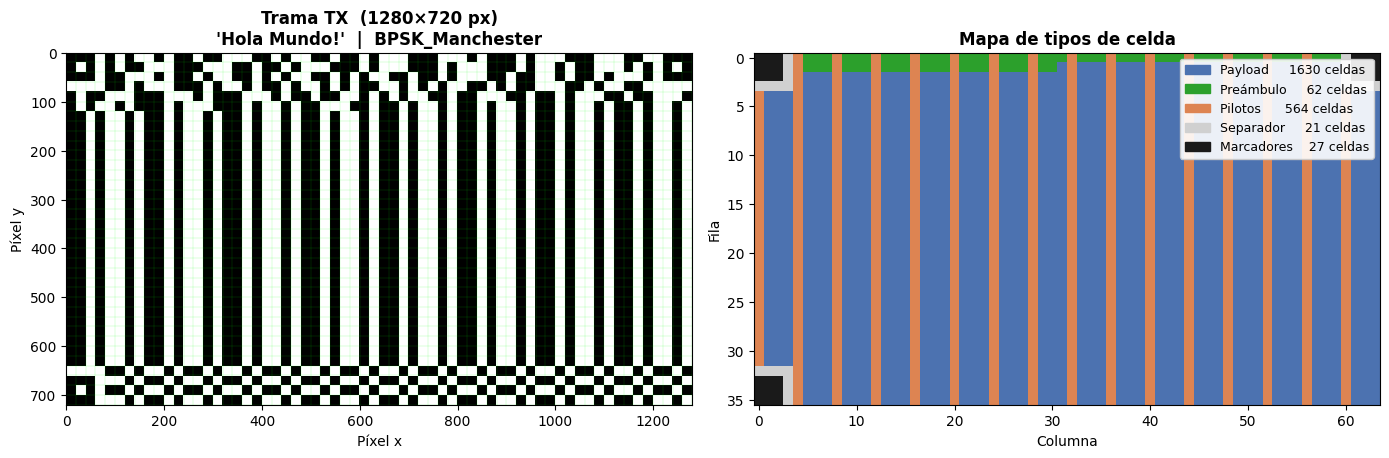

  Texto          : 'Hola Mundo!'
  Mensaje        : 88 bits  (11 bytes)
  Capacidad      : 815 bits  (101 bytes)
  Eficiencia     : 10.8%  (88/815 bits)
  Imagen         : 1280×720 px

  Celdas totales : 2304
  ├─ Marcadores  : 27
  ├─ Separadores : 21
  ├─ Pilotos     : 564
  ├─ Preámbulo   : 62
  └─ Payload     : 1630
  Guardado: frame_tx.png  (1280×720 px, 40.8 KB)


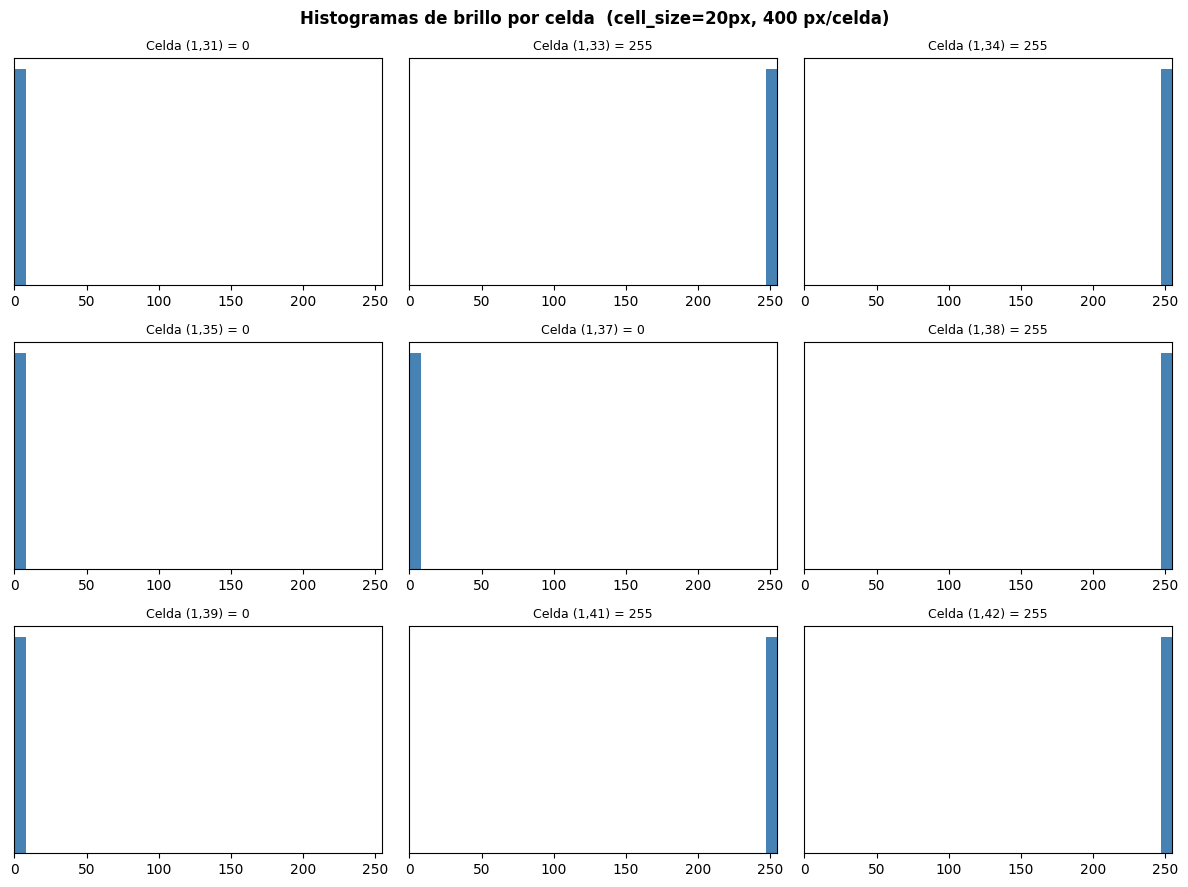

In [20]:
# ─────────────────────────────────────────────────────────────
#  CELDA 5: Ensamblador completo de trama
# ─────────────────────────────────────────────────────────────
#
#  Orden de pintado sobre el lienzo (importante para celdas no superpuestas):
#
#    1. Canvas gris medio (128) — valor neutro si alguna celda queda sin asignar
#    2. Pilotos              — celdas de calibración de brillo
#    3. Preámbulo            — chips Gold para sincronización
#    4. Payload              — datos del usuario (relleno con 0s al final)
#    5. Marcadores (último)  — finders + separadores blancos
#                             Sus celdas están RESERVADAS en el layout,
#                             por lo que nunca sobreescriben datos útiles.
# ─────────────────────────────────────────────────────────────

# ── 5.1 Ensamblador principal ─────────────────────────────────

def assemble_frame(text          : str,
                    config        : ModemConfig,
                    layout        : dict | None = None,
                    preamble_info : dict | None = None) -> dict:
    """
    Convierte texto en una imagen numpy uint8 lista para mostrar en pantalla.

    Acepta layout y preamble_info pre-calculados para reutilizarlos
    al transmitir múltiples tramas sin recalcular el mismo esqueleto.
    """
    # ── Reutilizar o calcular layout / preámbulo ──────────────
    if layout is None:
        layout = compute_frame_layout(config)
    if preamble_info is None:
        preamble_info = build_preamble(config, layout)

    cs         = config.cell_size
    data_cells = preamble_info["data_positions"]   # celdas limpias para payload
    n_data     = len(data_cells)

    # ── Capacidad máxima del payload ──────────────────────────
    if config.scheme == "BPSK_Manchester":
        max_bits = n_data // 2    # 2 chips por bit
    else:
        max_bits = n_data * 2     # 2 bits por símbolo

    # ── Codificar texto ───────────────────────────────────────
    raw_bits = text_to_bits(text)
    n_bits   = len(raw_bits)

    if n_bits > max_bits:
        raise ValueError(
            f"Mensaje demasiado largo: {n_bits} bits > {max_bits} disponibles "
            f"({max_bits // 8} bytes). "
            f"Acorta el texto o usa ModemConfig(M=20, N=20, cell_size=32)."
        )

    # Rellenar con ceros hasta cubrir exactamente todas las celdas de payload
    padded       = np.zeros(max_bits, dtype=np.uint8)
    padded[:n_bits] = raw_bits
    payload_syms = bits_to_symbols(padded, config)

    # ── 1. Canvas base ────────────────────────────────────────
    frame = np.full(
        (config.frame_height, config.frame_width), 128, dtype=np.uint8
    )

    # ── 2. Pilotos ────────────────────────────────────────────
    pilot_vals = generate_pilot_values(len(layout["pilot"]))
    for (r, c), val in zip(layout["pilot"], pilot_vals):
        frame[r*cs:(r+1)*cs, c*cs:(c+1)*cs] = int(val)

    # ── 3. Preámbulo ──────────────────────────────────────────
    for (r, c), val in zip(preamble_info["preamble_cells"],
                            preamble_info["symbols"]):
        frame[r*cs:(r+1)*cs, c*cs:(c+1)*cs] = int(val)

    # ── 4. Payload ────────────────────────────────────────────
    for i, (r, c) in enumerate(data_cells):
        if i < len(payload_syms):
            frame[r*cs:(r+1)*cs, c*cs:(c+1)*cs] = int(payload_syms[i])

    # ── 5. Marcadores (sobre celdas ya reservadas) ────────────
    draw_markers_on_frame(frame, layout, config)

    return {
        "frame"        : frame,
        "config"       : config,
        "layout"       : layout,
        "preamble"     : preamble_info,
        "text"         : text,
        "raw_bits"     : raw_bits,
        "padded_bits"  : padded,
        "payload_syms" : payload_syms,
        "capacity_bits": max_bits,
        "used_bits"    : n_bits,
        "efficiency"   : n_bits / max_bits if max_bits > 0 else 0.0,
    }


# ── 5.2 Visualización ─────────────────────────────────────────

def display_frame(fd         : dict,
                show_grid  : bool = True,
                show_layout: bool = True):
    """
    Panel izquierdo : trama en escala de grises con grid de celdas.
    Panel derecho   : mapa de colores con los 5 tipos de celda.
    """
    from matplotlib.colors import ListedColormap

    frame        = fd["frame"]
    config       = fd["config"]
    layout       = fd["layout"]
    preamb       = fd["preamble"]
    cs           = config.cell_size
    preamble_set = set(map(tuple, preamb["preamble_cells"]))

    n_cols = 2 if show_layout else 1
    fig, axes = plt.subplots(1, n_cols, figsize=(7 * n_cols, 6.5))
    if n_cols == 1:
        axes = [axes]

    # — Panel izquierdo: trama real —
    axes[0].imshow(frame, cmap='gray', vmin=0, vmax=255,
                    interpolation='nearest')
    axes[0].set_title(
        f"Trama TX  ({config.frame_width}×{config.frame_height} px)\n"
        f"'{fd['text']}'  |  {config.scheme}",
        fontweight='bold'
    )
    if show_grid:
        for k in range(0, config.frame_width  + 1, cs):
            axes[0].axvline(k - 0.5, color='lime', lw=0.3, alpha=0.35)
        for k in range(0, config.frame_height + 1, cs):
            axes[0].axhline(k - 0.5, color='lime', lw=0.3, alpha=0.35)
    axes[0].set_xlabel("Píxel x"); axes[0].set_ylabel("Píxel y")

    # — Panel derecho: mapa de tipos de celda —
    if show_layout:
        # Categorías: 0=payload  1=preámbulo  2=piloto  3=separador  4=marcador
        COLORS = ['#4C72B0', '#2ca02c', '#DD8452', '#D0D0D0', '#1a1a1a']
        cmap5  = ListedColormap(COLORS)

        grid = np.zeros((config.M, config.N), dtype=np.uint8)
        for pos in layout["data"]     : grid[pos] = 0
        for pos in layout["pilot"]    : grid[pos] = 2
        for pos in layout["separator"]: grid[pos] = 3
        for pos in layout["marker"]   : grid[pos] = 4
        for pos in preamble_set       : grid[pos] = 1  # sobreescribe payload

        axes[1].imshow(grid, cmap=cmap5, vmin=0, vmax=4,
                        interpolation='nearest')
        axes[1].set_title("Mapa de tipos de celda", fontweight='bold')
        axes[1].set_xlabel("Columna"); axes[1].set_ylabel("Fila")

        n_payload = len(preamb["data_positions"])
        patches = [
            mpatches.Patch(color=COLORS[0],
                            label=f"Payload    {n_payload:>5d} celdas"),
            mpatches.Patch(color=COLORS[1],
                            label=f"Preámbulo  {len(preamb['preamble_cells']):>5d} celdas"),
            mpatches.Patch(color=COLORS[2],
                            label=f"Pilotos    {len(layout['pilot']):>5d} celdas"),
            mpatches.Patch(color=COLORS[3],
                            label=f"Separador  {len(layout['separator']):>5d} celdas"),
            mpatches.Patch(color=COLORS[4],
                            label=f"Marcadores {len(layout['marker']):>5d} celdas"),
        ]
        axes[1].legend(handles=patches, fontsize=9,
                        loc='upper right', framealpha=0.9)

    plt.tight_layout(); plt.show()

    # — Desglose numérico —
    total = config.M * config.N
    print(f"  Texto          : '{fd['text']}'")
    print(f"  Mensaje        : {fd['used_bits']} bits  "
        f"({fd['used_bits'] // 8} bytes)")
    print(f"  Capacidad      : {fd['capacity_bits']} bits  "
        f"({fd['capacity_bits'] // 8} bytes)")
    print(f"  Eficiencia     : {fd['efficiency']*100:.1f}%  "
        f"({fd['used_bits']}/{fd['capacity_bits']} bits)")
    print(f"  Imagen         : {config.frame_width}×{config.frame_height} px")
    print()
    print(f"  Celdas totales : {total}")
    print(f"  ├─ Marcadores  : {len(layout['marker'])}")
    print(f"  ├─ Separadores : {len(layout['separator'])}")
    print(f"  ├─ Pilotos     : {len(layout['pilot'])}")
    print(f"  ├─ Preámbulo   : {len(preamb['preamble_cells'])}")
    print(f"  └─ Payload     : {len(preamb['data_positions'])}")


# ── 5.3 Exportar a PNG ────────────────────────────────────────

def save_frame(fd: dict, path: str = "frame_tx.png") -> str:
    """Guarda la trama como PNG en escala de grises."""
    if not cv2.imwrite(path, fd["frame"]):
        raise IOError(f"cv2.imwrite falló al guardar '{path}'")
    size_kb = os.path.getsize(path) / 1024
    print(f"  Guardado: {path}  "
        f"({fd['config'].frame_width}×{fd['config'].frame_height} px, "
        f"{size_kb:.1f} KB)")
    return path


# ── 5.4 Diagnóstico por región (histograma de brillo por celda) ──

def plot_cell_histograms(fd: dict, n_sample: int = 9):
    """
    Muestra el histograma de píxeles para n_sample celdas de payload.
    Útil para detectar si el cell_size es suficiente o si hay bordes suavizados.
    """
    config     = fd["config"]
    cs         = config.cell_size
    data_cells = fd["preamble"]["data_positions"][:n_sample]
    frame      = fd["frame"]

    cols = min(n_sample, 3)
    rows = (n_sample + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols,
                            figsize=(4 * cols, 3 * rows))
    axes = np.array(axes).flatten()

    for ax, (r, c) in zip(axes, data_cells):
        patch = frame[r*cs:(r+1)*cs, c*cs:(c+1)*cs].flatten()
        ax.hist(patch, bins=32, range=(0, 255),
                color='steelblue', edgecolor='none')
        ax.set_title(f"Celda ({r},{c}) = {int(patch.mean())}", fontsize=9)
        ax.set_xlim(0, 255); ax.set_yticks([])

    for ax in axes[n_sample:]:
        ax.axis('off')

    plt.suptitle(
        f"Histogramas de brillo por celda  "
        f"(cell_size={cs}px, {cs*cs} px/celda)",
        fontweight='bold'
    )
    plt.tight_layout(); plt.show()


# ── Ejecutar ──────────────────────────────────────────────────
TEST_TEXT = "Hola Mundo!"   # ~3 bytes; ajusta según capacidad de tu cfg

fd   = assemble_frame(TEST_TEXT, cfg, layout=layout, preamble_info=preamble)
display_frame(fd)
path = save_frame(fd)
plot_cell_histograms(fd)

── Caso A: loopback directo (sin canal) ──────────────


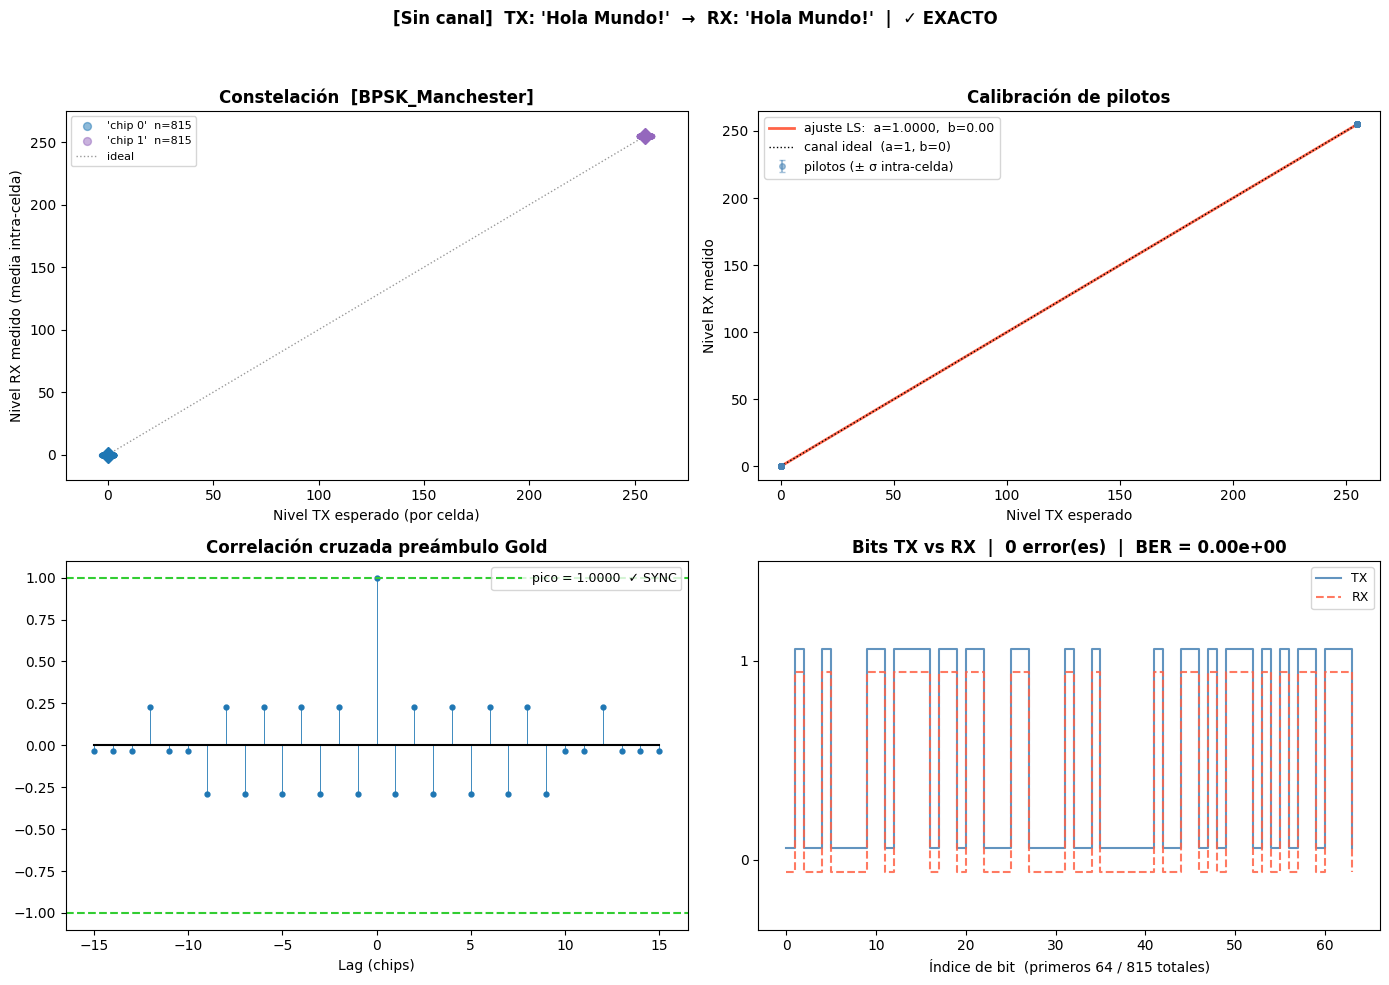

  TX           : 'Hola Mundo!'
  RX           : 'Hola Mundo!'
  Coincidencia : ✓ EXACTA
  BER          : 0.00e+00  (0 errores / 815 bits)
  Calibración  : a = 1.00000,   b = 0.000
  Preámbulo    : pico = 1.0000   lag = 0   ✓ sincronizado

── Caso B: loopback desde PNG ────────────────────────


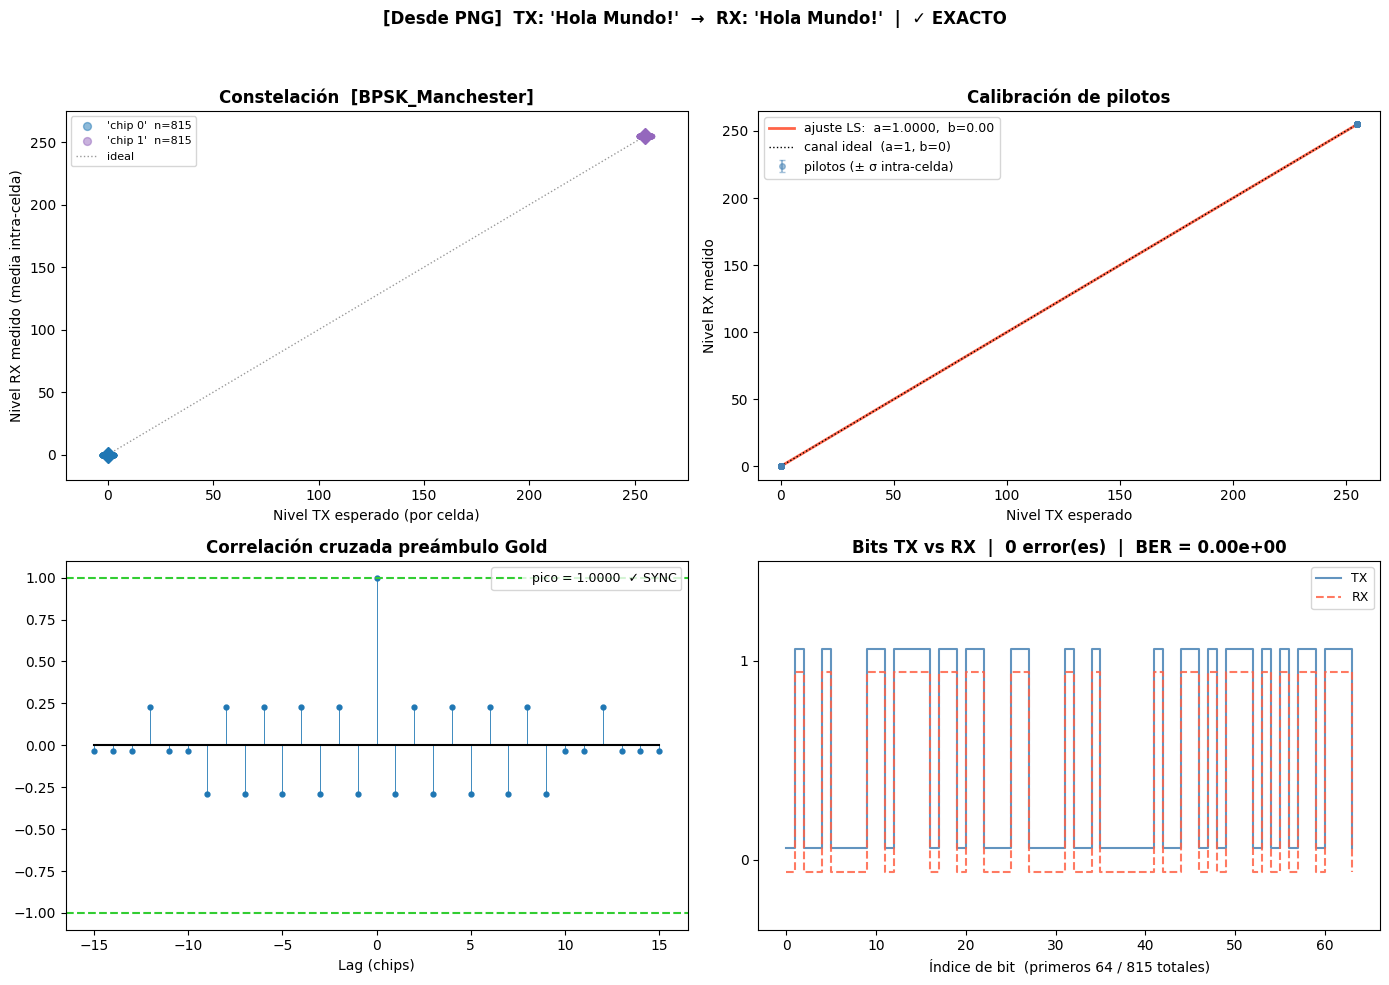

  TX           : 'Hola Mundo!'
  RX           : 'Hola Mundo!'
  Coincidencia : ✓ EXACTA
  BER          : 0.00e+00  (0 errores / 815 bits)
  Calibración  : a = 1.00000,   b = 0.000
  Preámbulo    : pico = 1.0000   lag = 0   ✓ sincronizado


In [21]:
# ─────────────────────────────────────────────────────────────
#  CELDA 6: Decodificador y verificación loopback
# ─────────────────────────────────────────────────────────────
#
#  Pipeline de recepción:
#
#    [Imagen PNG / frame en memoria]
#         │
#         ▼  extract_cell_values
#    valores medios por celda  (+ desv. estándar intra-celda)
#         │
#         ├─► pilotos  → calibrate_from_pilots  →  a, b
#         │
#         ├─► preámbulo (calibrado) → verify_preamble → correlación Gold
#         │
#         └─► payload  (calibrado) → symbols_to_bits → bits_to_text
# ─────────────────────────────────────────────────────────────

# ── 6.1 Extracción de valores de celdas ──────────────────────
#
#  Se usa un margen interior para evitar ISI espacial:
#  bordes entre celdas adyacentes que, al ser capturados por la cámara,
#  pueden mostrar valores intermedios por desenfoque y difracción.

def extract_cell_values(image        : np.ndarray,
                        config       : ModemConfig,
                        layout       : dict,
                        preamble_info: dict) -> dict:
    """
    Extrae (media, σ) de la zona interior de cada celda.
    margin = cell_size // 8  ≈ 12.5% de recorte por lado.
    """
    cs     = config.cell_size
    margin = max(1, cs // 8)

    def stats(r, c):
        patch = image[r*cs + margin : (r+1)*cs - margin,
                    c*cs + margin : (c+1)*cs - margin].astype(float)
        return patch.mean(), patch.std()

    def unzip_stats(positions):
        if not positions:
            return np.array([]), np.array([])
        means, stds = zip(*[stats(r, c) for r, c in positions])
        return np.array(means), np.array(stds)

    p_mu,  p_sg  = unzip_stats(layout["pilot"])
    pr_mu, pr_sg = unzip_stats(preamble_info["preamble_cells"])
    d_mu,  d_sg  = unzip_stats(preamble_info["data_positions"])

    return {
        "pilot_mean"   : p_mu,   "pilot_std"   : p_sg,
        "preamble_mean": pr_mu,  "preamble_std": pr_sg,
        "payload_mean" : d_mu,   "payload_std" : d_sg,
    }


# ── 6.2 Calibración lineal por mínimos cuadrados ─────────────
#
#  Modelo del canal: y_rx = a · y_tx + b  (+ ruido)
#  Inversión:        y_corr = (y_rx − b) / a
#
#  Con pilotos que alternan 0 ↔ 255:
#    •  b  = nivel recibido cuando TX = 0  (negro ambiente)
#    •  a  = (nivel_blanco − nivel_negro) / 255

def calibrate_from_pilots(received: np.ndarray,
                            expected: np.ndarray) -> tuple[float, float]:
    """Estimación de ganancia a y offset b por regresión lineal."""
    A      = np.column_stack([expected.astype(float),
                                np.ones(len(expected))])
    coef,*_ = np.linalg.lstsq(A, received.astype(float), rcond=None)
    return float(coef[0]), float(coef[1])


def apply_calibration(values: np.ndarray,
                        a: float, b: float) -> np.ndarray:
    """Invierte el canal y recorta al rango [0, 255]."""
    if abs(a) < 1e-9:
        return values.astype(float)
    return np.clip((values.astype(float) - b) / a, 0.0, 255.0)


# ── 6.3 Verificación del preámbulo ───────────────────────────

def verify_preamble(received_syms: np.ndarray,
                    preamble_info: dict,
                    config       : ModemConfig,
                    threshold    : float = 0.7) -> dict:
    """
    Demodula los chips del preámbulo y calcula la correlación cruzada
    circular contra la secuencia Gold esperada.
    Pico ≥ threshold → trama sincronizada.
    """
    expected_seq  = preamble_info["sequence"]
    received_bits = symbols_to_bits(received_syms.astype(np.uint8), config)

    n   = min(len(expected_seq), len(received_bits))
    exp = 2.0 * expected_seq[:n].astype(float) - 1.0   # BPSK: {0,1}→{-1,+1}
    rec = 2.0 * received_bits[:n].astype(float) - 1.0

    xc      = np.real(np.fft.ifft(np.fft.fft(rec) * np.conj(np.fft.fft(exp))))
    xc_norm = xc / n
    peak    = float(np.max(np.abs(xc_norm)))
    lag     = int(np.argmax(np.abs(xc_norm)))

    return {"peak": peak, "lag": lag, "synced": peak >= threshold, "xc": xc_norm}


# ── 6.4 Decodificador completo ────────────────────────────────

def decode_frame(image        : np.ndarray,
                config       : ModemConfig,
                layout       : dict,
                preamble_info: dict,
                apply_calib  : bool = True) -> dict:
    """
    Recupera el texto a partir de una imagen del frame.
    No requiere conocer el texto original: opera solo con
    config + layout + preamble_info (todos públicos/reproducibles).
    """
    # 1 · Extraer
    cells = extract_cell_values(image, config, layout, preamble_info)

    # 2 · Calibrar
    pilot_exp = generate_pilot_values(len(layout["pilot"])).astype(float)
    a, b      = calibrate_from_pilots(cells["pilot_mean"], pilot_exp)

    if apply_calib:
        pre_cal = apply_calibration(cells["preamble_mean"], a, b)
        pay_cal = apply_calibration(cells["payload_mean"],  a, b)
    else:
        a, b    = 1.0, 0.0
        pre_cal = cells["preamble_mean"].astype(float)
        pay_cal = cells["payload_mean"].astype(float)

    pre_u8 = np.clip(np.round(pre_cal), 0, 255).astype(np.uint8)
    pay_u8 = np.clip(np.round(pay_cal), 0, 255).astype(np.uint8)

    # 3 · Verificar preámbulo
    pcheck = verify_preamble(pre_u8, preamble_info, config)

    # 4 · Demodular payload
    rec_bits = symbols_to_bits(pay_u8, config)

    # 5 · Reconstruir texto (quitar padding de bytes nulos)
    rec_text = bits_to_text(rec_bits).rstrip('\x00')

    return {
        "text"          : rec_text,
        "rec_bits"      : rec_bits,
        "cells"         : cells,
        "a"             : a,
        "b"             : b,
        "preamble_check": pcheck,
        "pay_u8"        : pay_u8,
        "pre_u8"        : pre_u8,
    }


# ── 6.5 Comparación end-to-end ────────────────────────────────

def verify_loopback(fd      : dict,
                    rx_image: np.ndarray | None = None) -> dict:
    """
    rx_image = None  → usa fd['frame'] sin canal (baseline perfecto).
    rx_image = array → simula imagen capturada (PNG, cámara web, etc.).
    """
    img    = rx_image if rx_image is not None else fd["frame"]
    result = decode_frame(img, fd["config"], fd["layout"], fd["preamble"])

    tx = fd["padded_bits"]
    rx = result["rec_bits"]
    n  = min(len(tx), len(rx))

    result["tx_text"]    = fd["text"]
    result["tx_bits"]    = tx
    result["errors"]     = int(np.sum(tx[:n] != rx[:n]))
    result["ber"]        = result["errors"] / n if n > 0 else 1.0
    result["text_match"] = (result["text"] == fd["text"])
    return result


# ── 6.6 Visualización de resultados ──────────────────────────

def plot_decode_results(fd: dict, vr: dict, title_tag: str = ""):
    """
    Panel 1 – Constelación:   scatter TX esperado vs RX medido por celda
    Panel 2 – Calibración:    recta de ajuste de pilotos
    Panel 3 – Preámbulo:      correlación cruzada circular
    Panel 4 – Bits TX vs RX:  comparación bit a bit (errores en rojo)
    """
    config = fd["config"]
    layout = fd["layout"]
    cells  = vr["cells"]
    pc     = vr["preamble_check"]

    # Alinear longitudes TX / RX para la constelación
    tx_s = fd["payload_syms"].astype(float)
    rx_s = vr["pay_u8"].astype(float)
    nc   = min(len(tx_s), len(rx_s))
    tx_s, rx_s = tx_s[:nc], rx_s[:nc]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # ── Panel 1: Constelación ─────────────────────────────────
    ax = axes[0, 0]
    levels = [0, 255] if config.scheme == "BPSK_Manchester" else list(map(int, ASK4_LEVELS))
    lbl    = ({0:'chip 0', 255:'chip 1'}
            if config.scheme == "BPSK_Manchester"
            else {0:'00', 85:'01', 170:'11', 255:'10'})
    colors_p = plt.cm.tab10(np.linspace(0, 0.45, len(levels)))

    for lv, col in zip(levels, colors_p):
        mask = np.isclose(tx_s, lv)
        if mask.sum() == 0:
            continue
        jitter = np.random.uniform(-3, 3, mask.sum())
        ax.scatter(np.full(mask.sum(), lv) + jitter, rx_s[mask],
                    s=8, alpha=0.5, color=col,
                    label=f"'{lbl[lv]}'  n={mask.sum()}")
        ax.errorbar(lv, rx_s[mask].mean(), yerr=rx_s[mask].std(),
                    fmt='D', color=col, ms=8, capsize=5, zorder=6)

    ax.plot([0, 255], [0, 255], 'k:', lw=1, alpha=0.4, label='ideal')
    ax.set_xlabel("Nivel TX esperado (por celda)")
    ax.set_ylabel("Nivel RX medido (media intra-celda)")
    ax.set_title(f"Constelación  [{config.scheme}]", fontweight='bold')
    ax.legend(fontsize=8, markerscale=2)
    ax.set_xlim(-20, 275); ax.set_ylim(-20, 275)

    # ── Panel 2: Calibración de pilotos ──────────────────────
    ax = axes[0, 1]
    pilot_exp = generate_pilot_values(len(layout["pilot"])).astype(float)
    pilot_rx  = cells["pilot_mean"]
    pilot_sg  = cells["pilot_std"]

    ax.errorbar(pilot_exp, pilot_rx, yerr=pilot_sg,
                fmt='o', ms=4, alpha=0.5, color='steelblue',
                capsize=2, label='pilotos (± σ intra-celda)')
    x_l = np.array([0.0, 255.0])
    ax.plot(x_l, vr["a"] * x_l + vr["b"], color='tomato', lw=2,
            label=f"ajuste LS:  a={vr['a']:.4f},  b={vr['b']:.2f}")
    ax.plot(x_l, x_l, 'k:', lw=1, label='canal ideal  (a=1, b=0)')
    ax.set_xlabel("Nivel TX esperado"); ax.set_ylabel("Nivel RX medido")
    ax.set_title("Calibración de pilotos", fontweight='bold')
    ax.legend(fontsize=9); ax.set_xlim(-10, 265); ax.set_ylim(-10, 265)

    # ── Panel 3: Correlación del preámbulo ────────────────────
    ax = axes[1, 0]
    xc   = pc["xc"]
    L    = len(xc)
    lags = np.arange(L) - L // 2
    xcc  = np.roll(xc, L // 2)

    ml, sl, bl = ax.stem(lags, xcc, linefmt='C0-',
                        markerfmt='C0o', basefmt='k-')
    plt.setp(sl, linewidth=0.6); plt.setp(ml, markersize=3.5)

    c_pk = 'limegreen' if pc["synced"] else 'tomato'
    ax.axhline( pc["peak"], color=c_pk, ls='--', lw=1.5,
                label=f"pico = {pc['peak']:.4f}  "
                    f"{'✓ SYNC' if pc['synced'] else '✗ NO SYNC'}")
    ax.axhline(-pc["peak"], color=c_pk, ls='--', lw=1.5)
    ax.set_xlabel("Lag (chips)"); ax.legend(fontsize=9)
    ax.set_title("Correlación cruzada preámbulo Gold", fontweight='bold')

    # ── Panel 4: Bits TX vs RX ────────────────────────────────
    ax = axes[1, 1]
    n_show  = min(64, len(vr["tx_bits"]))
    tx_b    = vr["tx_bits"][:n_show].astype(float)
    rx_b    = vr["rec_bits"][:n_show].astype(float)
    err_idx = np.where(tx_b != rx_b)[0]

    ax.step(np.arange(n_show), tx_b + 0.06, where='post',
            color='steelblue', lw=1.5, label='TX', alpha=0.85)
    ax.step(np.arange(n_show), rx_b - 0.06, where='post',
            color='tomato', lw=1.5, ls='--', label='RX', alpha=0.85)
    for i in err_idx:
        ax.axvspan(i, i + 1, alpha=0.35, color='red')

    ax.set_ylim(-0.35, 1.5); ax.set_yticks([0, 1])
    ax.set_xlabel(f"Índice de bit  (primeros {n_show} / {len(vr['tx_bits'])} totales)")
    ax.set_title(
        f"Bits TX vs RX  |  {vr['errors']} error(es)  |  "
        f"BER = {vr['ber']:.2e}",
        fontweight='bold'
    )
    ax.legend(fontsize=9)

    status = "✓ EXACTO" if vr["text_match"] else "✗ ERROR"
    plt.suptitle(
        f"{title_tag}  TX: '{vr['tx_text']}'  →  "
        f"RX: '{vr['text']}'  |  {status}",
        fontweight='bold', fontsize=12
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

    print(f"  TX           : '{vr['tx_text']}'")
    print(f"  RX           : '{vr['text']}'")
    print(f"  Coincidencia : {'✓ EXACTA' if vr['text_match'] else '✗ FALLO'}")
    print(f"  BER          : {vr['ber']:.2e}  "
        f"({vr['errors']} errores / "
        f"{min(len(vr['tx_bits']), len(vr['rec_bits']))} bits)")
    print(f"  Calibración  : a = {vr['a']:.5f},   b = {vr['b']:.3f}")
    print(f"  Preámbulo    : pico = {pc['peak']:.4f}   "
        f"lag = {pc['lag']}   "
        f"{'✓ sincronizado' if pc['synced'] else '✗ no sync'}")


# ── Ejecutar ──────────────────────────────────────────────────

# Caso A: loopback directo en memoria (sin canal — baseline perfecto)
print("── Caso A: loopback directo (sin canal) ──────────────")
vr_direct = verify_loopback(fd)
plot_decode_results(fd, vr_direct, title_tag="[Sin canal]")

# Caso B: loopback desde PNG (verifica que cv2 preserva píxeles exactos)
print("\n── Caso B: loopback desde PNG ────────────────────────")
img_png = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
vr_png  = verify_loopback(fd, rx_image=img_png)
plot_decode_results(fd, vr_png, title_tag="[Desde PNG]")